In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import skew
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.seasonal import seasonal_decompose
from pandas.tseries.frequencies import infer_freq
from sklearn.ensemble import IsolationForest
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix


In [2]:
url = 'https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/machine_temperature_system_failure.csv'
df = pd.read_csv(url)
print(df.head())

df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
df.head()

             timestamp      value
0  2013-12-02 21:15:00  73.967322
1  2013-12-02 21:20:00  74.935882
2  2013-12-02 21:25:00  76.124162
3  2013-12-02 21:30:00  78.140707
4  2013-12-02 21:35:00  79.329836


,value
timestamp,
2013-12-02 21:15:00,73.967322
2013-12-02 21:20:00,74.935882
2013-12-02 21:25:00,76.124162
2013-12-02 21:30:00,78.140707
2013-12-02 21:35:00,79.329836


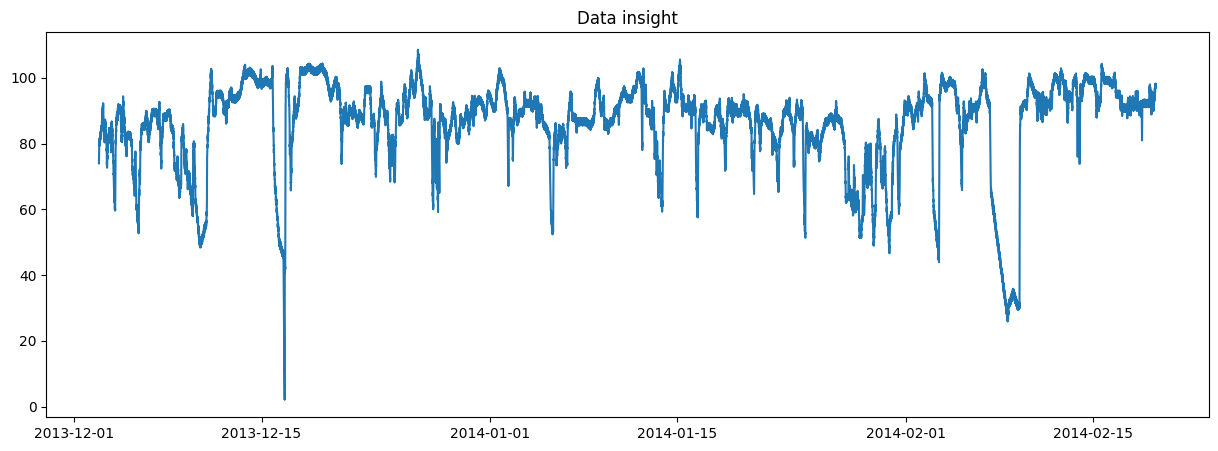

In [3]:
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['value'])
plt.title("Data insight")
plt.show()

In [4]:
print("Mean:", df['value'].mean())
print("Std:", df['value'].std())
print("Min:", df['value'].min())
print("Max:", df['value'].max())
print("Skewness:", skew(df['value']))

Mean: 85.92649821068021
Std: 13.746912473090102
Min: 2.084721206
Max: 108.5105428
Skewness: -1.8336859840742736


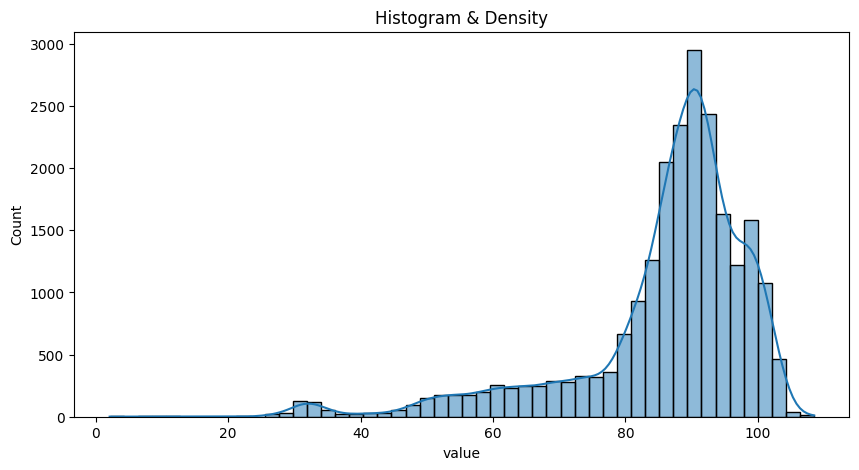

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df['value'], kde=True, bins=50) 
plt.title("Histogram & Density")
plt.show()

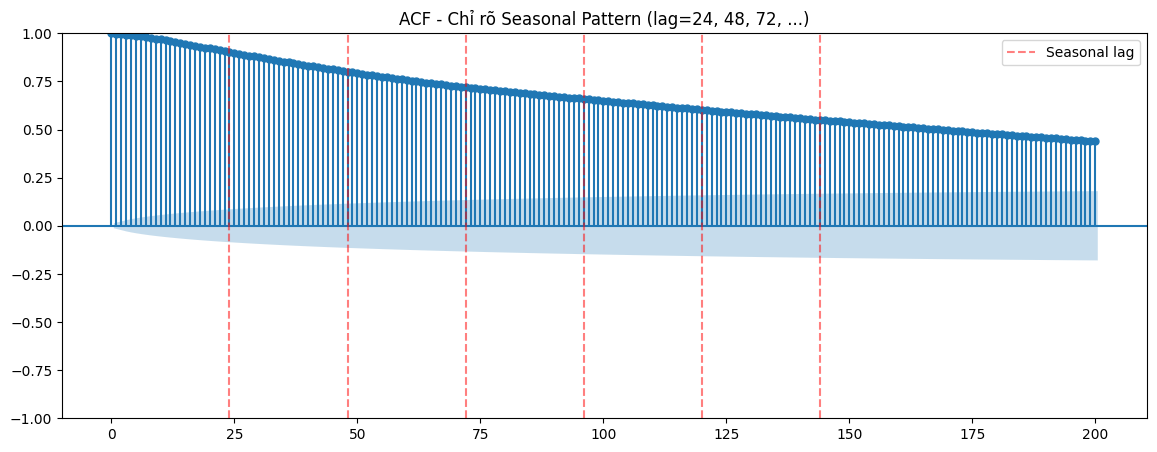

Autocorrelation at seasonal lags:
lag=  1: 0.997
lag= 13: 0.955
lag= 25: 0.898
lag= 37: 0.845
lag= 49: 0.797
lag= 61: 0.754
lag= 73: 0.718
lag= 85: 0.687
lag= 97: 0.657
lag=109: 0.629
lag=121: 0.601
lag=133: 0.574
lag=145: 0.549


In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
plot_acf(df['value'], lags=200, ax=ax)

for lag in [24, 48, 72, 96, 120, 144]:
    ax.axvline(x=lag, color='red', linestyle='--', alpha=0.5, label='Seasonal lag' if lag==24 else '')

ax.set_title('ACF - Chỉ rõ Seasonal Pattern (lag=24, 48, 72, ...)')
ax.legend()
plt.show()

print("Autocorrelation at seasonal lags:")
for lag in range(1, 150, 12):
    autocorr = df['value'].autocorr(lag)
    print(f"lag={lag:>3}: {autocorr:.3f}")

### Phase 1 conclusion:
+ The data shape is not a gaussian curve, it's a left skewed distribution. Tt's clear seasonal pattern, since the data curve is not gaussian distribution, thus STL + 3σ method is suit in this case

# Phase 2

STL + 3σ DETECTOR - SUMMARY
Period: 24
Threshold: 3.0-sigma
Total data points: 22695
Anomalies detected: 447
Anomaly rate: 1.97%
Residual mean: -0.2437
Residual std: 2.2827


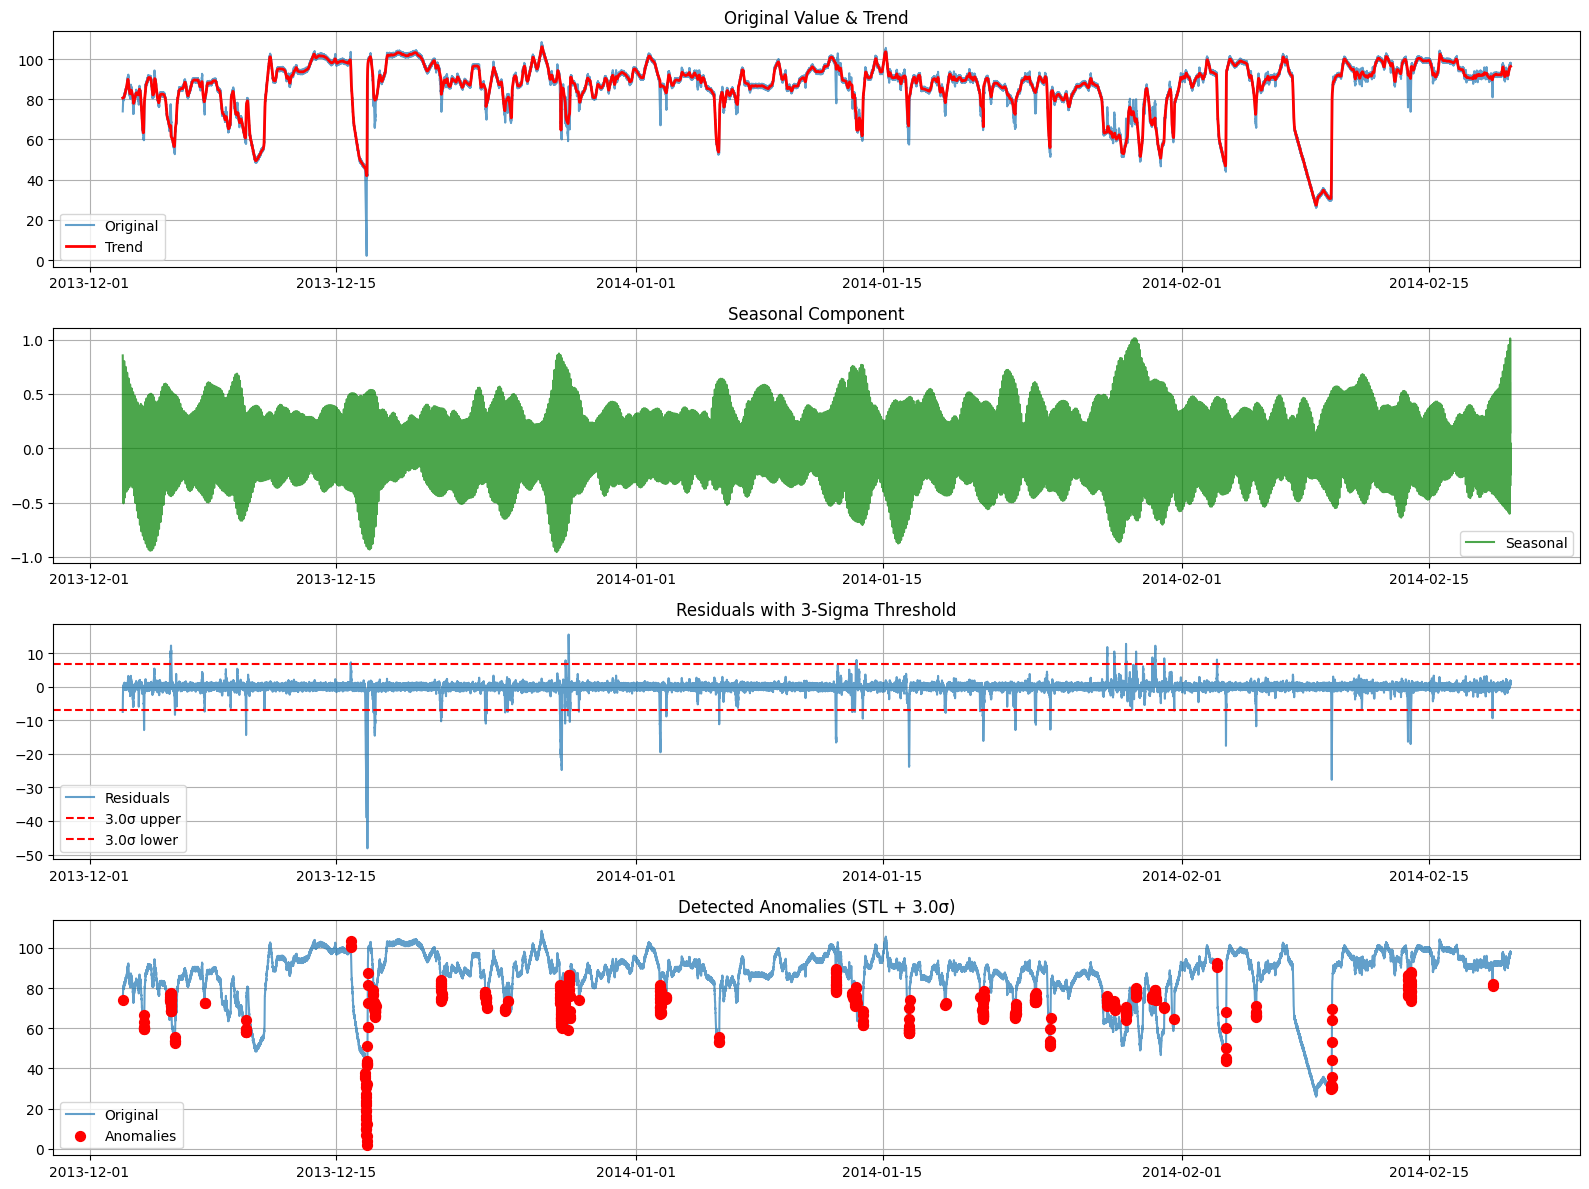


Top 10 anomalies by z-score magnitude:
                         value  stl_zscore
timestamp                                 
2013-12-16 18:30:00  43.925414  -20.988364
2013-12-16 18:25:00  41.790454  -20.585595
2013-12-16 18:20:00  42.495383  -18.938866
2013-12-16 18:35:00  51.003121  -18.456296
2013-12-16 17:25:00   2.084721  -17.003428
2013-12-16 18:15:00  42.551285  -16.509529
2013-12-16 17:20:00   4.117241  -16.445360
2013-12-16 17:15:00   6.440238  -15.632717
2013-12-16 17:10:00   6.918645  -15.254520
2013-12-16 18:40:00  60.535948  -14.938782


In [7]:


PERIOD = 24  
THRESHOLD = 3.0  

stl = STL(df["value"], period=PERIOD, robust=True, seasonal=25)
stl_result = stl.fit()

df["stl_trend"] = stl_result.trend
df["stl_seasonal"] = stl_result.seasonal
df["stl_resid"] = stl_result.resid

resid_mean = df["stl_resid"].mean()
resid_std = df["stl_resid"].std()
df["stl_zscore"] = (df["stl_resid"] - resid_mean) / resid_std

df["is_anomaly_stl"] = (df["stl_zscore"].abs() > THRESHOLD).astype(int)

print("=" * 60)
print("STL + 3σ DETECTOR - SUMMARY")
print("=" * 60)
print(f"Period: {PERIOD}")
print(f"Threshold: {THRESHOLD}-sigma")
print(f"Total data points: {len(df)}")
print(f"Anomalies detected: {df['is_anomaly_stl'].sum()}")
print(f"Anomaly rate: {df['is_anomaly_stl'].sum() / len(df) * 100:.2f}%")
print(f"Residual mean: {resid_mean:.4f}")
print(f"Residual std: {resid_std:.4f}")
print("=" * 60)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))

axes[0].plot(df.index, df['value'], label='Original', alpha=0.7)
axes[0].plot(df.index, df['stl_trend'], label='Trend', color='red', linewidth=2)
axes[0].set_title('Original Value & Trend')
axes[0].legend()
axes[0].grid()

axes[1].plot(df.index, df['stl_seasonal'], label='Seasonal', color='green', alpha=0.7)
axes[1].set_title('Seasonal Component')
axes[1].legend()
axes[1].grid()

axes[2].plot(df.index, df['stl_resid'], label='Residuals', alpha=0.7)
axes[2].axhline(y=THRESHOLD * resid_std, color='r', linestyle='--', label=f'{THRESHOLD}σ upper')
axes[2].axhline(y=-THRESHOLD * resid_std, color='r', linestyle='--', label=f'{THRESHOLD}σ lower')
axes[2].set_title('Residuals with 3-Sigma Threshold')
axes[2].legend()
axes[2].grid()

axes[3].plot(df.index, df['value'], label='Original', alpha=0.7)
anomaly_idx = df[df['is_anomaly_stl'] == 1].index
axes[3].scatter(anomaly_idx, df.loc[anomaly_idx, 'value'], 
                color='red', s=50, label='Anomalies', zorder=5)
axes[3].set_title(f'Detected Anomalies (STL + {THRESHOLD}σ)')
axes[3].legend()
axes[3].grid()

plt.tight_layout()
plt.savefig('detector_stl_visualization.png', dpi=100)
plt.show()

print("\nTop 10 anomalies by z-score magnitude:")
anomalies_detail = df[df['is_anomaly_stl'] == 1][['value', 'stl_trend', 'stl_seasonal', 'stl_zscore']].copy()
anomalies_detail['zscore_abs'] = anomalies_detail['stl_zscore'].abs()
top_anomalies = anomalies_detail.nlargest(10, 'zscore_abs')
print(top_anomalies[['value', 'stl_zscore']])

In [8]:
joblib.dump(stl_result, 'stl_model.pkl')
df.to_csv('predictions_stl.csv', index=True)

In [ ]:
def build_features(data, value_col="value"):
    features = pd.DataFrame(index=data.index)
    y = data[value_col]

    features["value"] = y
    features["lag_1"] = y.shift(1)
    features["lag_24"] = y.shift(24)      # 1 ngày trước
    features["lag_48"] = y.shift(48)      # 2 ngày trước
    
    features["diff_1"] = y.diff(1)
    features["diff_24"] = y.diff(24)
    
    features["rolling_mean_24"] = y.rolling(24, min_periods=1).mean()
    features["rolling_std_24"] = y.rolling(24, min_periods=1).std()
    features["rolling_min_24"] = y.rolling(24, min_periods=1).min()
    features["rolling_max_24"] = y.rolling(24, min_periods=1).max()
    
    features = features.fillna(0)
    return features

feature_table = build_features(df)
print(f"Feature table shape: {feature_table.shape}")
print(feature_table.head())


Feature table shape: (22695, 10)
                         value      lag_1  lag_24  lag_48    diff_1  diff_24  \
timestamp                                                                      
2013-12-02 21:15:00  73.967322   0.000000     0.0     0.0  0.000000      0.0   
2013-12-02 21:20:00  74.935882  73.967322     0.0     0.0  0.968560      0.0   
2013-12-02 21:25:00  76.124162  74.935882     0.0     0.0  1.188280      0.0   
2013-12-02 21:30:00  78.140707  76.124162     0.0     0.0  2.016546      0.0   
2013-12-02 21:35:00  79.329836  78.140707     0.0     0.0  1.189128      0.0   

                     rolling_mean_24  rolling_std_24  rolling_min_24  \
timestamp                                                              
2013-12-02 21:15:00        73.967322        0.000000       73.967322   
2013-12-02 21:20:00        74.451602        0.684875       73.967322   
2013-12-02 21:25:00        75.009122        1.080284       73.967322   
2013-12-02 21:30:00        75.792018        1.

In [ ]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(feature_table)

contamination_values = [0.01, 0.02, 0.05]
results_if = {}

print("\n" + "=" * 70)
print("ISOLATION FOREST - TUNING CONTAMINATION")
print("=" * 70)

for cont in contamination_values:
    print(f"\n🔹 Contamination = {cont}")
    
    iso_forest = IsolationForest(contamination=cont, random_state=42, n_estimators=100)
    predictions = iso_forest.fit_predict(features_scaled)
    
    anomalies = (predictions == -1).astype(int)
    
    n_anomalies = anomalies.sum()
    anomaly_rate = n_anomalies / len(anomalies) * 100
    
    print(f"  - Anomalies detected: {n_anomalies}")
    print(f"  - Anomaly rate: {anomaly_rate:.2f}%")
    
    results_if[cont] = {
        'iso_forest': iso_forest,
        'predictions': predictions,
        'anomalies': anomalies,
        'n_anomalies': n_anomalies,
        'anomaly_rate': anomaly_rate
    }

print("=" * 70)

best_contamination = 0.02  
best_anomalies = results_if[best_contamination]['anomalies']

df['is_anomaly_if'] = best_anomalies

print(f"\n Best contamination: {best_contamination}")
print(f" Total IF anomalies: {df['is_anomaly_if'].sum()}")
print(f" Feature table rows: {len(feature_table)}")
print(f" DataFrame rows: {len(df)}")



ISOLATION FOREST - TUNING CONTAMINATION

🔹 Contamination = 0.01
  - Anomalies detected: 227
  - Anomaly rate: 1.00%

🔹 Contamination = 0.02
  - Anomalies detected: 454
  - Anomaly rate: 2.00%

🔹 Contamination = 0.05
  - Anomalies detected: 1135
  - Anomaly rate: 5.00%

✅ Best contamination: 0.02
✅ Total IF anomalies: 454
✅ Feature table rows: 22695
✅ DataFrame rows: 22695


In [ ]:
best_contamination = 0.02
best_anomalies = results_if[best_contamination]['anomalies']

anomaly_series = pd.Series(best_anomalies, index=feature_table.index)
anomaly_full = anomaly_series.reindex(df.index, fill_value=False)
df['is_anomaly_if'] = anomaly_full.astype(int)

print(f"\n Best contamination: {best_contamination}")
print(f" Total IF anomalies: {df['is_anomaly_if'].sum()}")
print(f" Feature table rows: {len(feature_table)}")
print(f" DataFrame rows: {len(df)}")


✅ Best contamination: 0.02
✅ Total IF anomalies: 454
✅ Feature table rows: 22695
✅ DataFrame rows: 22695


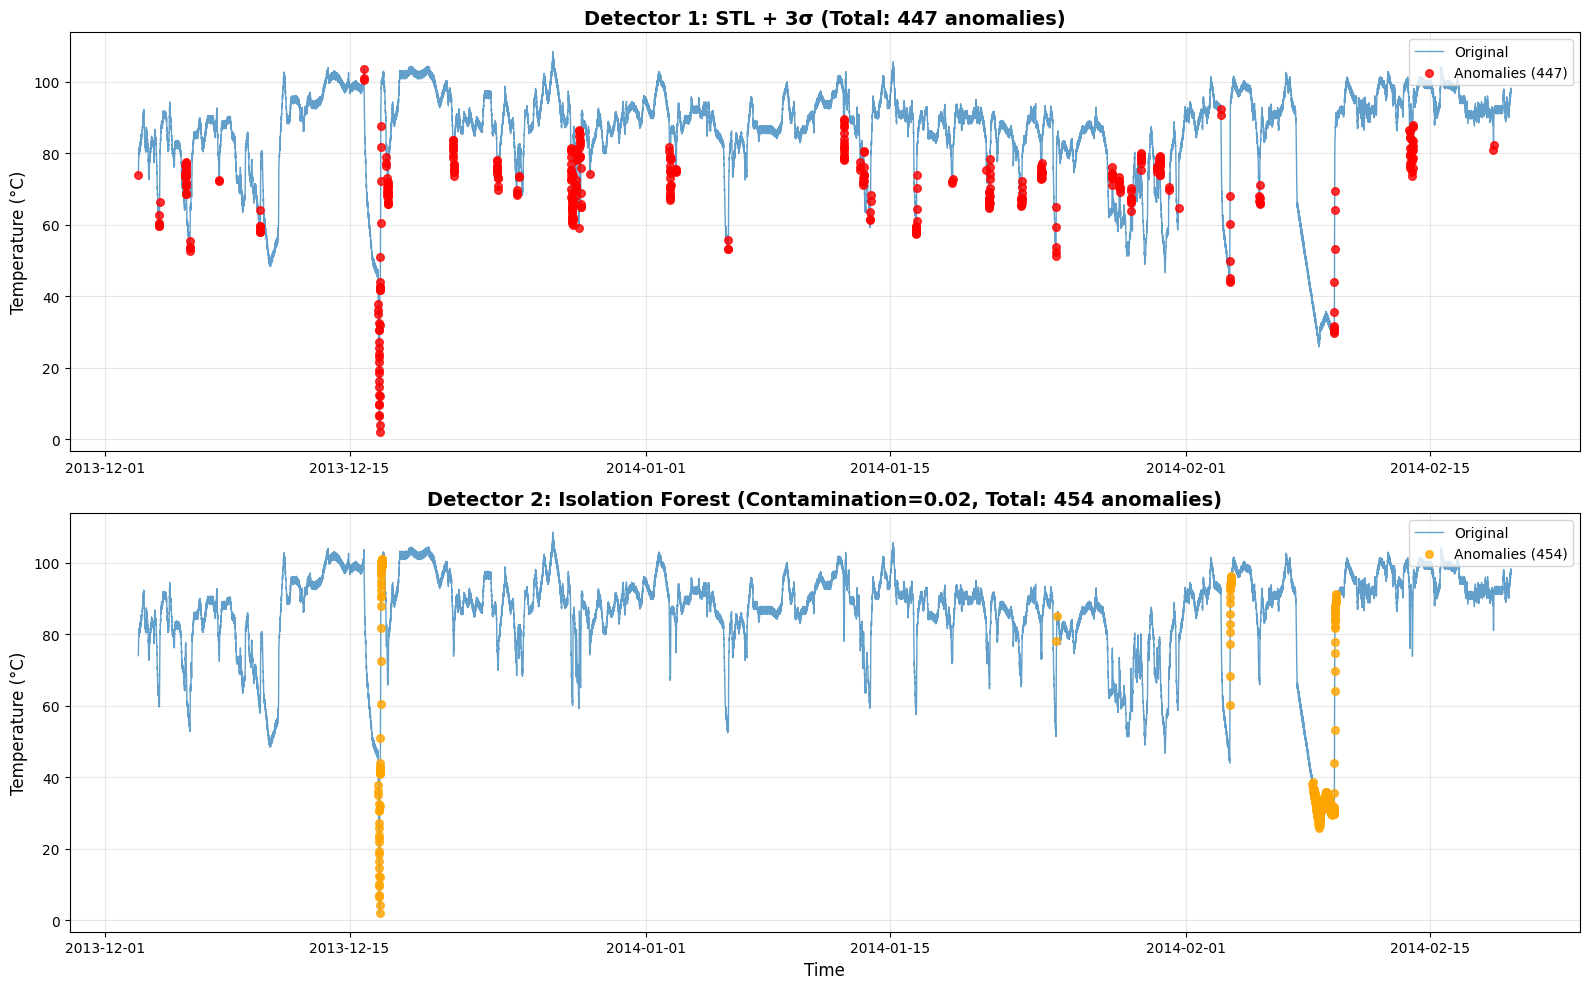

✅ Saved comparison plot: comparison_2_detectors.png
✅ Saved IF model & scaler


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(df.index, df['value'], label='Original', alpha=0.7, linewidth=1)
stl_anomaly_idx = df[df['is_anomaly_stl'] == 1].index
axes[0].scatter(stl_anomaly_idx, df.loc[stl_anomaly_idx, 'value'], 
                color='red', s=30, label=f'Anomalies ({len(stl_anomaly_idx)})', zorder=5, alpha=0.8)
axes[0].set_title(f'Detector 1: STL + 3σ (Total: {df["is_anomaly_stl"].sum()} anomalies)', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(alpha=0.3)
axes[0].set_ylabel('Temperature (°C)', fontsize=12)

axes[1].plot(df.index, df['value'], label='Original', alpha=0.7, linewidth=1)
if_anomaly_idx = df[df['is_anomaly_if'] == 1].index
axes[1].scatter(if_anomaly_idx, df.loc[if_anomaly_idx, 'value'], 
                color='orange', s=30, label=f'Anomalies ({len(if_anomaly_idx)})', zorder=5, alpha=0.8)
axes[1].set_title(f'Detector 2: Isolation Forest (Contamination={best_contamination}, Total: {df["is_anomaly_if"].sum()} anomalies)', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)
axes[1].set_xlabel('Time', fontsize=12)
axes[1].set_ylabel('Temperature (°C)', fontsize=12)

plt.tight_layout()
plt.savefig('comparison_2_detectors.png', dpi=100, bbox_inches='tight')
plt.show()

print(" Saved comparison plot: comparison_2_detectors.png")

joblib.dump(results_if[best_contamination]['iso_forest'], 'isolation_forest_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
print(" Saved IF model & scaler")

In [ ]:
print("\n" + "=" * 70)
print("SUMMARY STATISTICS")
print("=" * 70)

metrics_summary = pd.DataFrame({
    'STL + 3σ': {
        'Total Anomalies': df['is_anomaly_stl'].sum(),
        'Anomaly Rate (%)': df['is_anomaly_stl'].sum() / len(df) * 100
    },
    'Isolation Forest': {
        'Total Anomalies': df['is_anomaly_if'].sum(),
        'Anomaly Rate (%)': df['is_anomaly_if'].sum() / len(df) * 100
    }
})

print(metrics_summary.to_string())
print("\n" + "=" * 70)

overlap = ((df['is_anomaly_stl'] == 1) & (df['is_anomaly_if'] == 1)).sum()
print(f"\n Overlap (both detectors agree): {overlap} anomalies")
print(f"Only STL: {df['is_anomaly_stl'].sum() - overlap} anomalies")
print(f" Only IF: {df['is_anomaly_if'].sum() - overlap} anomalies")

df.to_csv('final_predictions_both_detectors.csv', index=True)
print("\n Saved final results: final_predictions_both_detectors.csv")


SUMMARY STATISTICS
                    STL + 3σ  Isolation Forest
Total Anomalies   447.000000        454.000000
Anomaly Rate (%)    1.969597          2.000441


📊 Overlap (both detectors agree): 48 anomalies
🔴 Only STL: 399 anomalies
🟠 Only IF: 406 anomalies

✅ Saved final results: final_predictions_both_detectors.csv
